1. Data Preparation

1.1 Importing Admissions and Patients CSV

In [1]:
import pandas as pd

#reading the patients and admissions csv
patients = pd.read_csv("patients.csv/patients.csv")
admissions = pd.read_csv("admissions.csv/admissions.csv")

print(patients.head(10))
print(admissions.head(10))

#merging the patients.csv and admission.csv based on subject_id
df = admissions.merge(patients, on="subject_id", how="left")
print(df.head())

   subject_id gender  anchor_age  anchor_year anchor_year_group        dod
0    10000032      F          52         2180       2014 - 2016   9/9/2180
1    10000048      F          23         2126       2008 - 2010        NaN
2    10000058      F          33         2168       2020 - 2022        NaN
3    10000068      F          19         2160       2008 - 2010        NaN
4    10000084      M          72         2160       2017 - 2019  2/13/2161
5    10000102      F          27         2136       2008 - 2010        NaN
6    10000108      M          25         2163       2014 - 2016        NaN
7    10000115      M          24         2154       2017 - 2019        NaN
8    10000117      F          48         2174       2008 - 2010        NaN
9    10000161      M          60         2163       2020 - 2022        NaN
   subject_id   hadm_id        admittime         dischtime deathtime  \
0    10000032  22595853   5/6/2180 22:23    5/7/2180 17:15       NaN   
1    10000032  22841357  6/26/2

1.2 Importing the services csv

In [2]:
#reading services csv
services = pd.read_csv("services.csv/services.csv")

print(services.head())
print(services.shape)

   subject_id   hadm_id         transfertime prev_service curr_service
0    10000032  22595853  2180-05-06 22:24:57          NaN          MED
1    10000032  22841357  2180-06-26 18:28:08          NaN          MED
2    10000032  25742920  2180-08-05 23:44:50          NaN          MED
3    10000032  29079034  2180-07-23 12:36:04          NaN          MED
4    10000068  25022803  2160-03-03 23:17:17          NaN          MED
(593071, 5)


1.3 Importing the diagnoses_icd csv and filtering only for MI patients

In [3]:
#reading the d_icd_diagnoses csv to identify MI related ICD codes
d_icd = pd.read_csv("d_icd_diagnoses.csv/d_icd_diagnoses.csv")

#filtering only MI-related ICD-9 and ICD-10 codes
icd9_mi = d_icd[(d_icd["icd_version"] == 9) & (d_icd["icd_code"].str.startswith("410")) & (d_icd["icd_code"].str.len() == 5)]
icd10_mi = d_icd[(d_icd["icd_version"] == 10) & (d_icd["icd_code"].str.startswith(("I21", "I22")))]

#combining ICD-9 and ICD-10 MI codes into a single list
MI_ICD_Codes = pd.concat([icd9_mi, icd10_mi])["icd_code"].unique().tolist()
print("Myocardial Infarction ICD codes:", MI_ICD_Codes)

#reading diagnoses_icd gz file directly
diagnoses_icd = pd.read_csv("diagnoses_icd.csv.gz")

#filtering MI related rows
mi_diagnoses = diagnoses_icd[diagnoses_icd["icd_code"].isin(MI_ICD_Codes)]

print("\n", "mi_diagnoses")
print(mi_diagnoses.head())
print("MI diagnosis rows:", mi_diagnoses.shape[0])
print("Unique patients:", mi_diagnoses["subject_id"].nunique())
print("Unique admissions:", mi_diagnoses["hadm_id"].nunique())
print(mi_diagnoses.shape)

df = df.merge(
    mi_diagnoses[["subject_id", "hadm_id"]].drop_duplicates(),
    on=["subject_id", "hadm_id"],
    how="inner"
)

print("\n", df.head(10))

mi_diagnoses.to_csv("mi_diagnoses.csv", index=False)

Myocardial Infarction ICD codes: ['41000', '41001', '41002', '41010', '41011', '41012', '41020', '41021', '41022', '41030', '41031', '41032', '41040', '41041', '41042', '41050', '41051', '41052', '41060', '41061', '41062', '41070', '41071', '41072', '41080', '41081', '41082', '41090', '41091', '41092', 'I21', 'I210', 'I2101', 'I2102', 'I2109', 'I211', 'I2111', 'I2119', 'I212', 'I2121', 'I2129', 'I213', 'I214', 'I219', 'I21A', 'I21A1', 'I21A9', 'I22', 'I220', 'I221', 'I222', 'I228', 'I229']

 mi_diagnoses
      subject_id   hadm_id  seq_num icd_code  icd_version
169     10000764  27897940        2    41071            9
417     10000980  26913865        1    41071            9
703     10001492  27463908        1    41071            9
1192    10002013  24760295        1    41071            9
1507    10002155  23822395        1    41011            9
MI diagnosis rows: 16829
Unique patients: 13152
Unique admissions: 16537
(16829, 5)

    subject_id   hadm_id         admittime         discht

2. Data Cleaning

2.1 Using only the curr_service used at admission - first service per admission

In [4]:
import numpy as np

services = services.sort_values(["subject_id", "hadm_id", "transfertime"])

services_final = services.drop_duplicates(
    subset=["subject_id", "hadm_id"],
    keep="first"
)[["subject_id", "hadm_id", "curr_service"]]

if "curr_service" in df.columns:
    df = df.drop(columns=["curr_service"])

#merging clean curr_service to df
df = df.merge(
    services_final,
    on=["subject_id", "hadm_id"],
    how="left"
)

2.2 Recording/adding ICD code and version for eaach admission (using seq_number)

In [5]:
mi_icd = mi_diagnoses.sort_values(["subject_id","hadm_id","seq_num"])

mi_icd = mi_icd.drop_duplicates(
    subset=["subject_id","hadm_id"]
)[["subject_id","hadm_id","icd_code","icd_version"]]

df = df.merge(
    mi_icd,
    on=["subject_id","hadm_id"],
    how="left"
)

2.3 Dropping duplicate admission rows

In [6]:
df = df.drop_duplicates(
    subset=["subject_id","hadm_id"]
).reset_index(drop=True)

2.4 Removing unnecessary rows/ keeping only required columns

In [7]:
#replacing empty columns with 'Unknown'
df["curr_service"] = df["curr_service"].fillna("UNKNOWN")

#Renaming anchor_age variable
df["age"] = df["anchor_age"]

columns = [
    "subject_id",
    "hadm_id",
    "admittime",
    "dischtime",
    "admission_type",
    "gender",
    "age",
    "curr_service",
    "hospital_expire_flag",
    "icd_code",
    "icd_version"
]

df = df[columns]

2.5 Other

In [8]:
# final checks

print("\nBEFORE")
print("Rows:", df.shape[0])
print("Unique admissions:", df[["subject_id", "hadm_id"]].drop_duplicates().shape[0])

#creating final dataset
MI_finaldf = df.copy()

print("\nAFTER")
print("Rows:", MI_finaldf.shape[0])
print("Unique admissions:", MI_finaldf[["subject_id", "hadm_id"]].drop_duplicates().shape[0])

print("\nFinal shape:", MI_finaldf.shape)
print("\n", MI_finaldf.head(5))

#saving cleaned dataset
MI_finaldf.to_csv("MI_finaldf.csv", index=False)


BEFORE
Rows: 16537
Unique admissions: 16537

AFTER
Rows: 16537
Unique admissions: 16537

Final shape: (16537, 11)

    subject_id   hadm_id         admittime         dischtime admission_type  \
0    10000764  27897940  10/14/2132 23:31  10/19/2132 16:30         URGENT   
1    10000980  26913865    6/27/2189 7:38     7/3/2189 3:00       EW EMER.   
2    10001492  27463908   9/23/2136 18:02   9/25/2136 17:45       EW EMER.   
3    10002013  24760295   7/10/2160 19:33   7/12/2160 12:30       EW EMER.   
4    10002155  23822395    8/4/2129 12:44   8/18/2129 16:53       EW EMER.   

  gender  age curr_service  hospital_expire_flag icd_code  icd_version  
0      M   86          MED                     0    41071            9  
1      F   73          MED                     0    41071            9  
2      F   71          MED                     0    41071            9  
3      F   53         CMED                     0    41071            9  
4      F   80         CMED                     0 

3. Data Engineering/ Variable creation

3.1 Creating Length of Stay Category (<7 or >7 days)

In [9]:
#converting admission and discharge time to datetime format
MI_finaldf["admittime"] = pd.to_datetime(MI_finaldf["admittime"])
MI_finaldf["dischtime"] = pd.to_datetime(MI_finaldf["dischtime"])

#calculating length of stay (LOS) in days
MI_finaldf["los_days"] = (
    (MI_finaldf["dischtime"] - MI_finaldf["admittime"])
    .dt.total_seconds() / (60 * 60 * 24)
)
MI_finaldf["los_days"] = MI_finaldf["los_days"].round(1)

#creating LOS categories:
MI_finaldf["los_cat"] = np.where(
    MI_finaldf["los_days"] < 7,
    "< 7 days",
    "≥ 7 days"
)
print(MI_finaldf[["admittime", "dischtime", "los_days", "los_cat"]].head())

            admittime           dischtime  los_days   los_cat
0 2132-10-14 23:31:00 2132-10-19 16:30:00       4.7  < 7 days
1 2189-06-27 07:38:00 2189-07-03 03:00:00       5.8  < 7 days
2 2136-09-23 18:02:00 2136-09-25 17:45:00       2.0  < 7 days
3 2160-07-10 19:33:00 2160-07-12 12:30:00       1.7  < 7 days
4 2129-08-04 12:44:00 2129-08-18 16:53:00      14.2  ≥ 7 days


3.2 Weekend effect (Weekend/Weekday flag)

In [10]:
#creating day-of-week variable from admission time (Monday=0, Sunday=6)
MI_finaldf["admit_dayofweek"] = MI_finaldf["admittime"].dt.dayofweek

#creating weekday vs weekend tag
MI_finaldf["admit_weekend"] = MI_finaldf["admit_dayofweek"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

#weekday vs weekend count check
print(MI_finaldf["admit_weekend"].value_counts())

#quick check with actual day names
tmp = MI_finaldf[["admittime"]].copy()
tmp["day_name"] = MI_finaldf["admittime"].dt.day_name()
tmp["dayofweek"] = MI_finaldf["admittime"].dt.dayofweek
print("\n",tmp.head(15))

admit_weekend
Weekday    11772
Weekend     4765
Name: count, dtype: int64

              admittime   day_name  dayofweek
0  2132-10-14 23:31:00    Tuesday          1
1  2189-06-27 07:38:00   Saturday          5
2  2136-09-23 18:02:00     Sunday          6
3  2160-07-10 19:33:00   Thursday          3
4  2129-08-04 12:44:00   Thursday          3
5  2141-05-22 20:17:00     Monday          0
6  2187-02-23 16:01:00     Friday          4
7  2111-01-02 19:21:00     Friday          4
8  2166-02-15 13:06:00   Saturday          5
9  2125-06-23 18:37:00   Saturday          5
10 2132-12-12 01:43:00     Friday          4
11 2111-11-13 23:39:00     Friday          4
12 2167-11-07 19:05:00   Saturday          5
13 2115-12-11 05:24:00  Wednesday          2
14 2111-04-12 17:51:00     Sunday          6


3.3 Prior MI admissions

In [11]:
#checking for prior MI admissions
MI_finaldf = MI_finaldf.sort_values(["subject_id", "admittime"]).reset_index(drop=True)
MI_finaldf["prior_mi"] = MI_finaldf.groupby("subject_id").cumcount().gt(0).map({True: "Y", False: "N"})

#quick check
print(MI_finaldf["prior_mi"].value_counts(dropna=False))
print(MI_finaldf.head())

prior_mi
N    13152
Y     3385
Name: count, dtype: int64
   subject_id   hadm_id           admittime           dischtime  \
0    10000764  27897940 2132-10-14 23:31:00 2132-10-19 16:30:00   
1    10000980  26913865 2189-06-27 07:38:00 2189-07-03 03:00:00   
2    10001492  27463908 2136-09-23 18:02:00 2136-09-25 17:45:00   
3    10002013  24760295 2160-07-10 19:33:00 2160-07-12 12:30:00   
4    10002155  23822395 2129-08-04 12:44:00 2129-08-18 16:53:00   

  admission_type gender  age curr_service  hospital_expire_flag icd_code  \
0         URGENT      M   86          MED                     0    41071   
1       EW EMER.      F   73          MED                     0    41071   
2       EW EMER.      F   71          MED                     0    41071   
3       EW EMER.      F   53         CMED                     0    41071   
4       EW EMER.      F   80         CMED                     0    41011   

   icd_version  los_days   los_cat  admit_dayofweek admit_weekend prior_mi  
0     

3.4 Other Diagnoses at admission

In [12]:
#quick check
mi_counts = (
    mi_diagnoses.groupby("hadm_id")
    .size()
    .reset_index(name="mi_code_count")
)

# admissions with more than one MI code
multiple_mi = mi_counts[mi_counts["mi_code_count"] > 1]

print("Admissions with multiple MI codes:", multiple_mi.shape[0])
print(multiple_mi.head())

Admissions with multiple MI codes: 284
      hadm_id  mi_code_count
68   20042196              2
70   20042619              2
196  20106942              2
278  20150907              2
295  20158935              2


In [13]:
#total diagnoses per admission
total_counts = diagnoses_icd["hadm_id"].value_counts()

#MI diagnoses per admission
mi_counts = mi_diagnoses["hadm_id"].value_counts().clip(upper=1)

#"other" diagnoses = total - 1 MI ICD code (in addition to one MI ICD since there are patients with multiple MI ICD's)
hadm_diag_counts = (total_counts - mi_counts).fillna(total_counts).to_dict()

#including counts to main dataset
MI_finaldf["num_diagnoses_at_admission"] = (MI_finaldf["hadm_id"].map(hadm_diag_counts).fillna(0).astype(int))

# quick check
print(MI_finaldf[["hadm_id", "num_diagnoses_at_admission"]].head())

    hadm_id  num_diagnoses_at_admission
0  27897940                          18
1  26913865                          14
2  27463908                           3
3  24760295                          14
4  23822395                          19


In [14]:
#quick check
#should 1 more than the above
example_id = 27897940 
count = (diagnoses_icd["hadm_id"] == example_id).sum()
print(count)

19


In [15]:
#quick check
diagnoses_icd[diagnoses_icd["hadm_id"] == 27897940].sort_values("seq_num")

,subject_id,hadm_id,seq_num,icd_code,icd_version
168,10000764,27897940,1,8020,9
169,10000764,27897940,2,41071,9
170,10000764,27897940,3,5849,9
171,10000764,27897940,4,2875,9
172,10000764,27897940,5,7802,9
173,10000764,27897940,6,7847,9
174,10000764,27897940,7,41401,9
175,10000764,27897940,8,28860,9
176,10000764,27897940,9,79902,9
177,10000764,27897940,10,2724,9


3.5 Readmission group

In [16]:
#sorting by patient and admission time
MI_finaldf = MI_finaldf.sort_values(["subject_id", "admittime"]).reset_index(drop=True)

#next MI admission
MI_finaldf["next_admittime"] = MI_finaldf.groupby("subject_id")["admittime"].shift(-1)

#days to next MI admission
MI_finaldf["days_to_readmit"] = (MI_finaldf["next_admittime"] - MI_finaldf["dischtime"]).dt.days

#30-day readmission flag
MI_finaldf["readmit_30d"] = np.where( MI_finaldf["days_to_readmit"].between(0, 30, inclusive="both"),1,0)

#quick check
print(MI_finaldf["readmit_30d"].value_counts())

MI_finaldf.to_csv("MI_final_dataset.csv", index=False)
print(MI_finaldf.shape)

readmit_30d
0    15117
1     1420
Name: count, dtype: int64
(16537, 20)


4. Dataset preparation for Length of Stay (LOS) modelling

4.1 Setting predictors and targets - creating a Data frame for Modelling for Length of Stay (LOS) 

In [17]:
#predictors
predictor_cols = [
    "age",
    "gender",
    "admission_type",
    "curr_service",
    "admit_weekend",
    "prior_mi",
    "num_diagnoses_at_admission"
]

#targets
target_cols = ["los_cat","readmit_30d","hospital_expire_flag"]

#building a separate dataframe for modelling
Finalmodel_df = MI_finaldf[predictor_cols + target_cols + ["subject_id"]].copy()

#quick checks
print("Rows:", Finalmodel_df.shape[0])
print("Columns:", Finalmodel_df.shape[1])
print("\nMissing values per column:")
print(Finalmodel_df.isna().sum())


print("\nTarget distributions:")

print("\nLOS category:")
print(Finalmodel_df["los_cat"].value_counts(dropna=False))

print("\n30-day Readmission:")
print(Finalmodel_df["readmit_30d"].value_counts(dropna=False))

print("\nMortality (hospital_expire_flag):")
print(Finalmodel_df["hospital_expire_flag"].value_counts(dropna=False))

print(Finalmodel_df.head(10))

#saving modelling dataset
Finalmodel_df.to_csv("Finalmodel_df.csv", index=False, encoding="utf-8-sig")

Rows: 16537
Columns: 11

Missing values per column:
age                           0
gender                        0
admission_type                0
curr_service                  0
admit_weekend                 0
prior_mi                      0
num_diagnoses_at_admission    0
los_cat                       0
readmit_30d                   0
hospital_expire_flag          0
subject_id                    0
dtype: int64

Target distributions:

LOS category:
los_cat
< 7 days    10053
≥ 7 days     6484
Name: count, dtype: int64

30-day Readmission:
readmit_30d
0    15117
1     1420
Name: count, dtype: int64

Mortality (hospital_expire_flag):
hospital_expire_flag
0    14993
1     1544
Name: count, dtype: int64
   age gender     admission_type curr_service admit_weekend prior_mi  \
0   86      M             URGENT          MED       Weekday        N   
1   73      F           EW EMER.          MED       Weekend        N   
2   71      F           EW EMER.          MED       Weekend        N   
3 

4.2 Creating Train Test split

In [18]:
from sklearn.model_selection import train_test_split

#spliting unique patients into train and test dfs (80/20)
train_patients, test_patients = train_test_split(Finalmodel_df["subject_id"].unique(), test_size=0.2, random_state=42)

#train/test dataframes using patient split
train_df = Finalmodel_df[Finalmodel_df["subject_id"].isin(train_patients)].copy()
test_df  = Finalmodel_df[Finalmodel_df["subject_id"].isin(test_patients)].copy()

#dropping subject_id from features and creating x y variables for LOS and readmission
X_train = train_df.drop(columns=["los_cat", "readmit_30d", "hospital_expire_flag", "subject_id"])
y_train_los,y_train_readmit,y_train_mortality = train_df["los_cat"], train_df["readmit_30d"], train_df["hospital_expire_flag"]
X_test = test_df.drop(columns=["los_cat", "readmit_30d", "hospital_expire_flag", "subject_id"])
y_test_los, y_test_readmit, y_test_mortality = test_df["los_cat"], test_df["readmit_30d"], test_df["hospital_expire_flag"]

#quick checks
print("Train rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])
print("Train patients:", train_df["subject_id"].nunique(), "| Test patients:", test_df["subject_id"].nunique())
print("Patient overlap:", len(set(train_df["subject_id"]) & set(test_df["subject_id"])))


Train rows: 13256 | Test rows: 3281
Train patients: 10521 | Test patients: 2631
Patient overlap: 0


4.3 Encoding variables

In [19]:
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

#categorical and numeric columns
cat_cols = ["gender","admission_type","curr_service","admit_weekend","prior_mi"]
num_cols = ["age", "num_diagnoses_at_admission"]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat  = encoder.transform(X_test[cat_cols])

#numeric features
X_train_num = X_train[num_cols].astype(float).values
X_test_num  = X_test[num_cols].astype(float).values

#combining categorical and numeric features into final matrices
X_train_enc = hstack([X_train_cat, X_train_num])
X_test_enc  = hstack([X_test_cat, X_test_num])

print("X_train_enc:", X_train_enc.shape, "| X_test_enc:", X_test_enc.shape)

#quick checks
print("\nNum features:", num_cols)
print("\nFirst 20 OHE features:", encoder.get_feature_names_out(cat_cols))

print("\nTrain LOS distribution:")
print(y_train_los.value_counts(normalize=True))

print("\nTest LOS distribution:")
print(y_test_los.value_counts(normalize=True))

print("\nTrain Readmission distribution:")
print(y_train_readmit.value_counts(normalize=True))

print("\nTest Readmission distribution:")
print(y_test_readmit.value_counts(normalize=True))

print("\nTrain Mortality distribution:")
print(y_train_mortality.value_counts(normalize=True))

print("\nTest Mortality distribution:")
print(y_test_mortality.value_counts(normalize=True))

X_train_enc: (13256, 36) | X_test_enc: (3281, 36)

Num features: ['age', 'num_diagnoses_at_admission']

First 20 OHE features: ['gender_F' 'gender_M' 'admission_type_AMBULATORY OBSERVATION'
 'admission_type_DIRECT EMER.' 'admission_type_DIRECT OBSERVATION'
 'admission_type_ELECTIVE' 'admission_type_EU OBSERVATION'
 'admission_type_EW EMER.' 'admission_type_OBSERVATION ADMIT'
 'admission_type_SURGICAL SAME DAY ADMISSION' 'admission_type_URGENT'
 'curr_service_CMED' 'curr_service_CSURG' 'curr_service_ENT'
 'curr_service_EYE' 'curr_service_GU' 'curr_service_GYN'
 'curr_service_MED' 'curr_service_NMED' 'curr_service_NSURG'
 'curr_service_OBS' 'curr_service_OMED' 'curr_service_ORTHO'
 'curr_service_PSURG' 'curr_service_PSYCH' 'curr_service_SURG'
 'curr_service_TRAUM' 'curr_service_TSURG' 'curr_service_UNKNOWN'
 'curr_service_VSURG' 'admit_weekend_Weekday' 'admit_weekend_Weekend'
 'prior_mi_N' 'prior_mi_Y']

Train LOS distribution:
los_cat
< 7 days    0.608856
≥ 7 days    0.391144
Name: prop

5. Length of Stay Modelling and Evaluation

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score , f1_score

5.1 Logistic Regression for LOS

In [21]:
logreg_los = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")

#training the model on training data
logreg_los.fit(X_train_enc, y_train_los)

#predictions on the test set
y_pred_los = logreg_los.predict(X_test_enc)
y_prob_los = logreg_los.predict_proba(X_test_enc)[:, 1]

#evaluation
print("Accuracy (Logistic Regression - LOS):", round(accuracy_score(y_test_los, y_pred_los), 4))
print("\nClassification Report (Logistic Regression - LOS):\n", classification_report(y_test_los, y_pred_los))
print("Confusion Matrix (Logistic Regression - LOS):\n", confusion_matrix(y_test_los, y_pred_los))

#LOS to binary for ROC-AUC
y_test_los_bin = (y_test_los == "≥ 7 days").astype(int)
print("ROC-AUC (Logistic Regression - LOS):", round(roc_auc_score(y_test_los_bin, y_prob_los), 4))


Accuracy (Logistic Regression - LOS): 0.7476

Classification Report (Logistic Regression - LOS):
               precision    recall  f1-score   support

    < 7 days       0.81      0.76      0.78      1982
    ≥ 7 days       0.67      0.73      0.70      1299

    accuracy                           0.75      3281
   macro avg       0.74      0.74      0.74      3281
weighted avg       0.75      0.75      0.75      3281

Confusion Matrix (Logistic Regression - LOS):
 [[1509  473]
 [ 355  944]]
ROC-AUC (Logistic Regression - LOS): 0.8278


5.2 Decision Tree for LOS

In [22]:
decisiontree_los = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced")

#training the model
decisiontree_los.fit(X_train_enc, y_train_los)

#predictions
y_pred_dt = decisiontree_los.predict(X_test_enc)
y_prob_dt = decisiontree_los.predict_proba(X_test_enc)[:, 1]

#evaluation
print("\nAccuracy (Decision Tree - LOS):", round(accuracy_score(y_test_los, y_pred_dt), 4))
print("\nClassification Report (Decision Tree - LOS):\n", classification_report(y_test_los, y_pred_dt))
print("Confusion Matrix (Decision Tree - LOS):\n", confusion_matrix(y_test_los, y_pred_dt))
print("ROC-AUC (Decision Tree - LOS):", round(roc_auc_score(y_test_los_bin, y_prob_dt), 4))


Accuracy (Decision Tree - LOS): 0.7388

Classification Report (Decision Tree - LOS):
               precision    recall  f1-score   support

    < 7 days       0.82      0.73      0.77      1982
    ≥ 7 days       0.65      0.75      0.69      1299

    accuracy                           0.74      3281
   macro avg       0.73      0.74      0.73      3281
weighted avg       0.75      0.74      0.74      3281

Confusion Matrix (Decision Tree - LOS):
 [[1449  533]
 [ 324  975]]
ROC-AUC (Decision Tree - LOS): 0.814


5.3 Random Forest for LOS

In [23]:
randomforest_los = RandomForestClassifier(n_estimators=200,max_depth=8,class_weight="balanced",random_state=42)

#training the model
randomforest_los.fit(X_train_enc, y_train_los)

#predictions
y_pred_rf = randomforest_los.predict(X_test_enc)
y_prob_rf = randomforest_los.predict_proba(X_test_enc)[:, 1]

#evaluation
print("\nAccuracy (Random Forest - LOS):", round(accuracy_score(y_test_los, y_pred_rf), 4))
print("\nClassification Report (Random Forest - LOS):\n", classification_report(y_test_los, y_pred_rf))
print("Confusion Matrix (Random Forest - LOS):\n", confusion_matrix(y_test_los, y_pred_rf))
print("ROC-AUC (Random Forest - LOS):", round(roc_auc_score(y_test_los_bin, y_prob_rf), 4))



Accuracy (Random Forest - LOS): 0.7351

Classification Report (Random Forest - LOS):
               precision    recall  f1-score   support

    < 7 days       0.83      0.70      0.76      1982
    ≥ 7 days       0.63      0.79      0.70      1299

    accuracy                           0.74      3281
   macro avg       0.73      0.74      0.73      3281
weighted avg       0.75      0.74      0.74      3281

Confusion Matrix (Random Forest - LOS):
 [[1388  594]
 [ 275 1024]]
ROC-AUC (Random Forest - LOS): 0.8184


5.4 Gradient Boosting for LOS

In [24]:
gradientboosting_los = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)

#training the model
gradientboosting_los.fit(X_train_enc, y_train_los)

#predictions
y_pred_gb = gradientboosting_los.predict(X_test_enc)
y_prob_gb = gradientboosting_los.predict_proba(X_test_enc)[:, 1]

#evaluation
print("Accuracy (Gradient Boosting - LOS):", round(accuracy_score(y_test_los, y_pred_gb), 4))
print("\nClassification Report (Gradient Boosting - LOS):\n", classification_report(y_test_los, y_pred_gb))
print("Confusion Matrix (Gradient Boosting - LOS):\n", confusion_matrix(y_test_los, y_pred_gb))
print("ROC-AUC (Gradient Boosting - LOS):",  round(roc_auc_score(y_test_los_bin, y_prob_gb), 4))

Accuracy (Gradient Boosting - LOS): 0.758

Classification Report (Gradient Boosting - LOS):
               precision    recall  f1-score   support

    < 7 days       0.78      0.84      0.81      1982
    ≥ 7 days       0.72      0.64      0.68      1299

    accuracy                           0.76      3281
   macro avg       0.75      0.74      0.74      3281
weighted avg       0.76      0.76      0.76      3281

Confusion Matrix (Gradient Boosting - LOS):
 [[1657  325]
 [ 469  830]]
ROC-AUC (Gradient Boosting - LOS): 0.8283


5.5 Cat boost for LOS

In [25]:
catboost_los = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    random_seed=42,
    verbose=False
)

#training the model 
catboost_los.fit(X_train_enc, y_train_los)

#predictions
y_pred_cb = catboost_los.predict(X_test_enc)
y_prob_cb = catboost_los.predict_proba(X_test_enc)[:, 1]

#evaluation
print("\nAccuracy (CatBoost - LOS):", round(accuracy_score(y_test_los, y_pred_cb), 4))
print("\nClassification Report (CatBoost - LOS):\n", classification_report(y_test_los, y_pred_cb))
print("Confusion Matrix (CatBoost - LOS):\n", confusion_matrix(y_test_los, y_pred_cb))
print("ROC-AUC (CatBoost - LOS):", round(roc_auc_score(y_test_los_bin, y_prob_cb), 4))


Accuracy (CatBoost - LOS): 0.7482

Classification Report (CatBoost - LOS):
               precision    recall  f1-score   support

    < 7 days       0.77      0.83      0.80      1982
    ≥ 7 days       0.70      0.63      0.66      1299

    accuracy                           0.75      3281
   macro avg       0.74      0.73      0.73      3281
weighted avg       0.75      0.75      0.75      3281

Confusion Matrix (CatBoost - LOS):
 [[1638  344]
 [ 482  817]]
ROC-AUC (CatBoost - LOS): 0.8228


5.6 Support Vector Machine (SVM) for LOS

In [26]:
svm_los = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

#training the model
svm_los.fit(X_train_enc, y_train_los)

#predictions
y_pred_svm = svm_los.predict(X_test_enc)
y_prob_svm = svm_los.predict_proba(X_test_enc)[:, 1]

#evaluation
print("\n", "Accuracy (SVM - LOS):", round(accuracy_score(y_test_los, y_pred_svm), 4))
print("\nClassification Report (SVM - LOS):\n", classification_report(y_test_los, y_pred_svm))
print("Confusion Matrix (SVM - LOS):\n", confusion_matrix(y_test_los, y_pred_svm))
print("ROC-AUC (SVM - LOS):", round(roc_auc_score(y_test_los_bin, y_prob_svm), 4))


 Accuracy (SVM - LOS): 0.726

Classification Report (SVM - LOS):
               precision    recall  f1-score   support

    < 7 days       0.81      0.71      0.76      1982
    ≥ 7 days       0.63      0.75      0.68      1299

    accuracy                           0.73      3281
   macro avg       0.72      0.73      0.72      3281
weighted avg       0.74      0.73      0.73      3281

Confusion Matrix (SVM - LOS):
 [[1410  572]
 [ 327  972]]
ROC-AUC (SVM - LOS): 0.814


5.7 LOS model comparison

In [27]:
models = {
    "Logistic Regression": logreg_los,
    "Decision Tree": decisiontree_los,
    "Random Forest": randomforest_los,
    "Gradient Boosting": gradientboosting_los,
    "CatBoost": catboost_los,
    "SVM": svm_los
}

comparison_results = []

for name, model in models.items():

    y_pred = model.predict(X_test_enc)
    y_prob = model.predict_proba(X_test_enc)[:, 1]

    report = classification_report(y_test_los, y_pred, output_dict=True)

    comparison_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test_los, y_pred), 4),
        "Precision": round(report["≥ 7 days"]["precision"], 4),
        "Recall": round(report["≥ 7 days"]["recall"], 4),
        "F1-score": round(report["≥ 7 days"]["f1-score"], 4),
        "ROC-AUC": round(roc_auc_score(y_test_los_bin, y_prob), 4)
    })

comparison_df = pd.DataFrame(comparison_results).sort_values("ROC-AUC", ascending=False)

print(comparison_df)

                 Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
3    Gradient Boosting    0.7580     0.7186  0.6390    0.6764   0.8283
0  Logistic Regression    0.7476     0.6662  0.7267    0.6951   0.8278
4             CatBoost    0.7482     0.7037  0.6289    0.6642   0.8228
2        Random Forest    0.7351     0.6329  0.7883    0.7021   0.8184
1        Decision Tree    0.7388     0.6466  0.7506    0.6947   0.8140
5                  SVM    0.7260     0.6295  0.7483    0.6838   0.8140


5.8 Hyper parameter tuning and finding the best model

In [28]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

5.8.1 Gradient Boosting Hyperparameter Tuning (LOS)

In [29]:
#binary LOS for ROC-AUC
y_train_los_bin = (y_train_los == "≥ 7 days").astype(int)

#5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gb_base = GradientBoostingClassifier(random_state=42)

#hyperparameters
param_dist = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

#randomized search over parameters
gb_search = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_dist,
    n_iter=12,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

#tuning on train data
gb_search.fit(X_train_enc, y_train_los_bin)

#sort and check
results_df = pd.DataFrame(gb_search.cv_results_)

summary = results_df[
    ["mean_test_score","param_n_estimators","param_learning_rate","param_max_depth","param_subsample"]
].sort_values(by="mean_test_score", ascending=False)

summary["mean_test_score"] = summary["mean_test_score"].round(4)
summary.reset_index(drop=True, inplace=True)

print("\nAll CV Results (sorted by ROC-AUC):")
display(summary)

#best model
best_gb = gb_search.best_estimator_

#evaluation on test set
y_prob_test = best_gb.predict_proba(X_test_enc)[:, 1]
test_auc = roc_auc_score(y_test_los_bin, y_prob_test)

print("\nBest Hyperparameters:", gb_search.best_params_)
print("Best CV ROC-AUC:", round(gb_search.best_score_, 4))
print("Test ROC-AUC:", round(test_auc, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

All CV Results (sorted by ROC-AUC):


,mean_test_score,param_n_estimators,param_learning_rate,param_max_depth,param_subsample
0,0.8222,200,0.03,4,0.8
1,0.8220,600,0.03,2,1.0
2,0.8220,400,0.03,3,0.8
3,0.8219,400,0.03,2,1.0
4,0.8218,200,0.05,2,1.0
5,0.8215,200,0.03,4,1.0
6,0.8193,600,0.03,4,1.0
7,0.8185,200,0.1,4,1.0
8,0.8179,400,0.05,4,0.8
9,0.8170,200,0.1,4,0.8



Best Hyperparameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03}
Best CV ROC-AUC: 0.8222
Test ROC-AUC: 0.8283


5.8.2 Logistic Regression Hyperparameter Tuning (LOS)

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_base = LogisticRegression(max_iter=2000, random_state=42)

param_dist = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"],
    "class_weight": [None, "balanced"]
}

lr_search = RandomizedSearchCV(
    estimator=lr_base,
    param_distributions=param_dist,
    n_iter=8,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

#tuning
lr_search.fit(X_train_enc, y_train_los_bin)

#sort and check
results_df = pd.DataFrame(lr_search.cv_results_)

summary = results_df[
    ["mean_test_score","param_C","param_solver","param_class_weight"]
].sort_values(by="mean_test_score", ascending=False)

summary["mean_test_score"] = summary["mean_test_score"].round(4)
summary.reset_index(drop=True, inplace=True)

print("\nAll CV Results (sorted by ROC-AUC):")
display(summary)

#best model
best_lr = lr_search.best_estimator_

#evaluation on test set
y_prob_test = best_lr.predict_proba(X_test_enc)[:, 1]
test_auc = roc_auc_score(y_test_los_bin, y_prob_test)

print("\nBest Hyperparameters:", lr_search.best_params_)
print("Best CV ROC-AUC:", round(lr_search.best_score_, 4))
print("Test ROC-AUC:", round(test_auc, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits

All CV Results (sorted by ROC-AUC):


,mean_test_score,param_C,param_solver,param_class_weight
0,0.8230,1,liblinear,balanced
1,0.8229,1,liblinear,None
2,0.8229,1,lbfgs,None
3,0.8228,10,lbfgs,balanced
4,0.8228,10,liblinear,None
5,0.8226,0.1,liblinear,None
6,0.8193,0.01,lbfgs,None
7,0.8175,0.01,liblinear,None



Best Hyperparameters: {'solver': 'liblinear', 'class_weight': 'balanced', 'C': 1}
Best CV ROC-AUC: 0.823
Test ROC-AUC: 0.8278


5.8.3 CatBoost Hyperparameter Tuning (LOS)

In [31]:
cb_base = CatBoostClassifier(random_seed=42,verbose=0)

param_dist = {
    "iterations": [300, 600, 900],
    "learning_rate": [0.03, 0.05, 0.1],
    "depth": [4, 6, 8],
    "l2_leaf_reg": [1, 3, 5]
}

cb_search = RandomizedSearchCV(
    estimator=cb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

#tuning 
cb_search.fit(X_train_enc, y_train_los_bin)

#sort and check
results_df = pd.DataFrame(cb_search.cv_results_)

summary = results_df[
    ["mean_test_score","param_iterations","param_learning_rate","param_depth","param_l2_leaf_reg"]
].sort_values(by="mean_test_score", ascending=False)

summary["mean_test_score"] = summary["mean_test_score"].round(4)
summary.reset_index(drop=True, inplace=True)

print("\nAll CV Results (sorted by ROC-AUC):")
display(summary)

#best model
best_cb = cb_search.best_estimator_

#evaluation on test set
y_prob_test = best_cb.predict_proba(X_test_enc)[:, 1]
test_auc = roc_auc_score(y_test_los_bin, y_prob_test)

print("\nBest Hyperparameters:", cb_search.best_params_)
print("Best CV ROC-AUC:", round(cb_search.best_score_, 4))
print("Test ROC-AUC:", round(test_auc, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits

All CV Results (sorted by ROC-AUC):


,mean_test_score,param_iterations,param_learning_rate,param_depth,param_l2_leaf_reg
0,0.8234,300,0.03,4,1
1,0.8227,300,0.03,6,3
2,0.8224,300,0.05,4,3
3,0.8220,600,0.03,4,3
4,0.8209,300,0.05,6,3
5,0.8205,900,0.03,4,1
6,0.8201,600,0.05,4,1
7,0.8199,300,0.05,6,1
8,0.8189,900,0.05,4,3
9,0.8125,600,0.05,8,5



Best Hyperparameters: {'learning_rate': 0.03, 'l2_leaf_reg': 1, 'iterations': 300, 'depth': 4}
Best CV ROC-AUC: 0.8234
Test ROC-AUC: 0.829


5.9 Comparing tuned models (GB, LR, CB)

In [32]:
roc_compare = comparison_df[
    comparison_df["Model"].isin(
        ["Logistic Regression", "Gradient Boosting", "CatBoost"]
    )
][["Model", "ROC-AUC"]].copy()

# Compute tuned ROC-AUC
for name, model in {
    "Logistic Regression": best_lr,
    "Gradient Boosting": best_gb,
    "CatBoost": best_cb
}.items():

    y_prob = model.predict_proba(X_test_enc)[:, 1]

    roc_compare.loc[roc_compare["Model"] == name, "Tuned ROC-AUC"] = round(
        roc_auc_score(y_test_los_bin, y_prob), 4
    )

roc_compare

,Model,ROC-AUC,Tuned ROC-AUC
3,Gradient Boosting,0.8283,0.8283
0,Logistic Regression,0.8278,0.8278
4,CatBoost,0.8228,0.8290


5.9.1 Evaluating the best model

In [33]:
#final LOS model (CatBoost)
final_los_model = best_cb

#training on full training data
final_los_model.fit(X_train_enc, y_train_los)

CatBoostClassifier(depth=4, iterations=300, l2_leaf_reg=1, learning_rate=0.03, random_seed=42, verbose=0)

In [34]:
#predictions
y_pred = final_los_model.predict(X_test_enc)
y_prob = final_los_model.predict_proba(X_test_enc)[:, 1]

#metrics
final_acc = round(accuracy_score(y_test_los, y_pred), 4)
final_auc = round(roc_auc_score(y_test_los_bin, y_prob), 4)

print("Final LOS CatBoost model")
print("Accuracy:", final_acc)
print("ROC-AUC:", final_auc)

print("\nConfusion Matrix")
print(confusion_matrix(y_test_los, y_pred, labels=["< 7 days", "≥ 7 days"]))

print("\nClassification Report:")
print(classification_report(y_test_los, y_pred))

Final LOS CatBoost model
Accuracy: 0.7571
ROC-AUC: 0.829

Confusion Matrix
[[1656  326]
 [ 471  828]]

Classification Report:
              precision    recall  f1-score   support

    < 7 days       0.78      0.84      0.81      1982
    ≥ 7 days       0.72      0.64      0.68      1299

    accuracy                           0.76      3281
   macro avg       0.75      0.74      0.74      3281
weighted avg       0.75      0.76      0.75      3281



5.10 Saving the final and best model

In [35]:
import joblib

joblib.dump(final_los_model, "Final_LOS_Model.pkl")
print("Saved:", "Final_LOS_Model.pkl")

Saved: Final_LOS_Model.pkl


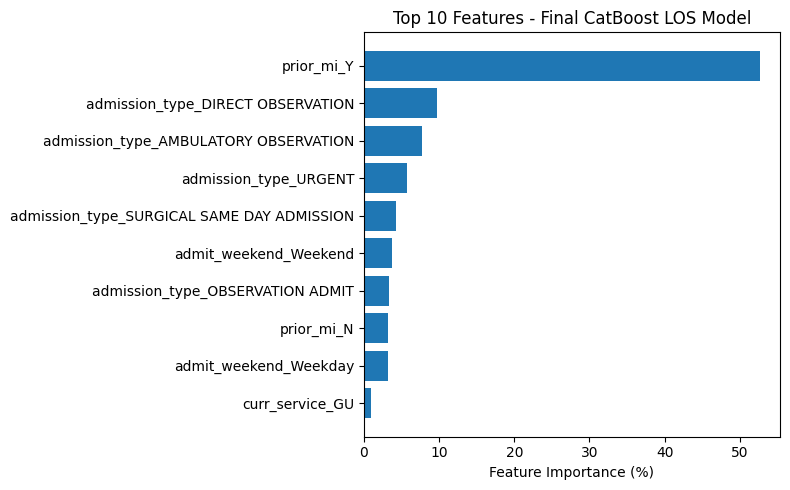

In [36]:
import matplotlib.pyplot as plt

#feature importance
all_features = num_cols + list(encoder.get_feature_names_out(cat_cols))

fi_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": final_los_model.get_feature_importance()
}).sort_values("Importance", ascending=False)

#top 10 plot
top10 = fi_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1])
plt.xlabel("Feature Importance (%)")
plt.title("Top 10 Features - Final CatBoost LOS Model")
plt.tight_layout()
plt.show()

6. Patient Mortality Prediction at admission Modelling and Evaluation 

In [37]:
from sklearn.metrics import recall_score, average_precision_score

#mortality target
y_train_mort = train_df["hospital_expire_flag"]
y_test_mort  = test_df["hospital_expire_flag"]

print("Train mortality distribution:")
print(y_train_mort.value_counts(normalize=True))

print("\nTest mortality distribution:")
print(y_test_mort.value_counts(normalize=True))

print(y_train_mort.value_counts())

#(1 = died in hospital, 0 = survived)

Train mortality distribution:
hospital_expire_flag
0    0.90525
1    0.09475
Name: proportion, dtype: float64

Test mortality distribution:
hospital_expire_flag
0    0.912222
1    0.087778
Name: proportion, dtype: float64
hospital_expire_flag
0    12000
1     1256
Name: count, dtype: int64


6.1 Logistic regression for Mortality prediction

In [38]:
mort_lr = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)

#training the model
mort_lr.fit(X_train_enc, y_train_mort)

#predictions
y_pred_lr = mort_lr.predict(X_test_enc)
y_prob_lr = mort_lr.predict_proba(X_test_enc)[:, 1]

#metrics
recall = recall_score(y_test_mort, y_pred_lr)
f1 = f1_score(y_test_mort, y_pred_lr)
roc_auc = roc_auc_score(y_test_mort, y_prob_lr)

cm = confusion_matrix(y_test_mort, y_pred_lr)
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])

auprc = average_precision_score(y_test_mort, y_prob_lr)

print("Recall (Logistic Regression - Mortality):", round(recall, 4))
print("Specificity (Logistic Regression - Mortality):", round(specificity, 4))
print("F1-score (Logistic Regression - Mortality):", round(f1, 4))
print("ROC-AUC (Logistic Regression - Mortality):", round(roc_auc, 4))
print("AUPRC (Logistic Regression - Mortality):", round(auprc, 4))
print("Confusion Matrix (Logistic Regression - Mortality):\n", cm)

Recall (Logistic Regression - Mortality): 0.6632
Specificity (Logistic Regression - Mortality): 0.6966
F1-score (Logistic Regression - Mortality): 0.2754
ROC-AUC (Logistic Regression - Mortality): 0.741
AUPRC (Logistic Regression - Mortality): 0.1887
Confusion Matrix (Logistic Regression - Mortality):
 [[2085  908]
 [  97  191]]


6.2 Random Forest for Mortality prediction

In [39]:
mort_rf = RandomForestClassifier(n_estimators=200,max_depth=8,class_weight="balanced",random_state=42)

#training the model 
mort_rf.fit(X_train_enc, y_train_mort)

#predictions
y_pred_rf = mort_rf.predict(X_test_enc)
y_prob_rf = mort_rf.predict_proba(X_test_enc)[:, 1]

#evaluation
recall = recall_score(y_test_mort, y_pred_rf)
f1 = f1_score(y_test_mort, y_pred_rf)
roc_auc = roc_auc_score(y_test_mort, y_prob_rf)

cm = confusion_matrix(y_test_mort, y_pred_rf)
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])

auprc = average_precision_score(y_test_mort, y_prob_rf)

print("Recall (Random Forest - Mortality):", round(recall, 4))
print("Specificity (Random Forest - Mortality):", round(specificity, 4))
print("F1-score (Random Forest - Mortality):", round(f1, 4))
print("ROC-AUC (Random Forest - Mortality):", round(roc_auc, 4))
print("AUPRC (Random Forest - Mortality):", round(auprc, 4))
print("Confusion Matrix (Random Forest - Mortality):\n", cm)

Recall (Random Forest - Mortality): 0.6701
Specificity (Random Forest - Mortality): 0.6889
F1-score (Random Forest - Mortality): 0.2734
ROC-AUC (Random Forest - Mortality): 0.7474
AUPRC (Random Forest - Mortality): 0.186
Confusion Matrix (Random Forest - Mortality):
 [[2062  931]
 [  95  193]]


6.3 Gradient Boosting for Mortality prediction

In [40]:
mort_gb = GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,random_state=42)

#training the model 
mort_gb.fit(X_train_enc, y_train_mort)

#predictions
y_pred_gb = mort_gb.predict(X_test_enc)
y_prob_gb = mort_gb.predict_proba(X_test_enc)[:, 1]

#evaluation
recall = recall_score(y_test_mort, y_pred_gb)
f1 = f1_score(y_test_mort, y_pred_gb)
roc_auc = roc_auc_score(y_test_mort, y_prob_gb)

cm = confusion_matrix(y_test_mort, y_pred_gb)
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])

auprc = average_precision_score(y_test_mort, y_prob_gb)

print("Recall (Gradient Boosting - Mortality):", round(recall, 4))
print("Specificity (Gradient Boosting - Mortality):", round(specificity, 4))
print("F1-score (Gradient Boosting - Mortality):", round(f1, 4))
print("ROC-AUC (Gradient Boosting - Mortality):", round(roc_auc, 4))
print("AUPRC (Gradient Boosting - Mortality):", round(auprc, 4))
print("Confusion Matrix (Gradient Boosting - Mortality):\n", cm)

Recall (Gradient Boosting - Mortality): 0.0035
Specificity (Gradient Boosting - Mortality): 0.9997
F1-score (Gradient Boosting - Mortality): 0.0069
ROC-AUC (Gradient Boosting - Mortality): 0.7443
AUPRC (Gradient Boosting - Mortality): 0.1874
Confusion Matrix (Gradient Boosting - Mortality):
 [[2992    1]
 [ 287    1]]


6.4 Catboost for Mortality prediction

In [41]:
mort_cb = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

#training the model 
mort_cb.fit(X_train_enc, y_train_mort)

# predictions
y_pred_cb = mort_cb.predict(X_test_enc)
y_prob_cb = mort_cb.predict_proba(X_test_enc)[:, 1]

#evaluation
recall = recall_score(y_test_mort, y_pred_cb)
f1 = f1_score(y_test_mort, y_pred_cb)
roc_auc = roc_auc_score(y_test_mort, y_prob_cb)

cm = confusion_matrix(y_test_mort, y_pred_cb)
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])

auprc = average_precision_score(y_test_mort, y_prob_cb)

print("Recall (CatBoost - Mortality):", round(recall, 4))
print("Specificity (CatBoost - Mortality):", round(specificity, 4))
print("F1-score (CatBoost - Mortality):", round(f1, 4))
print("ROC-AUC (CatBoost - Mortality):", round(roc_auc, 4))
print("AUPRC (CatBoost - Mortality):", round(auprc, 4))
print("Confusion Matrix (CatBoost - Mortality):\n", cm)

Recall (CatBoost - Mortality): 0.0208
Specificity (CatBoost - Mortality): 0.9963
F1-score (CatBoost - Mortality): 0.0393
ROC-AUC (CatBoost - Mortality): 0.7365
AUPRC (CatBoost - Mortality): 0.1835
Confusion Matrix (CatBoost - Mortality):
 [[2982   11]
 [ 282    6]]


6.5 Mortality risk model comparison

In [42]:
mort_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting", "CatBoost"],
    
    "ROC-AUC": [
        roc_auc_score(y_test_mort, y_prob_lr),
        roc_auc_score(y_test_mort, y_prob_rf),
        roc_auc_score(y_test_mort, y_prob_gb),
        roc_auc_score(y_test_mort, y_prob_cb)
    ],
    
    "Recall": [
        recall_score(y_test_mort, y_pred_lr),
        recall_score(y_test_mort, y_pred_rf),
        recall_score(y_test_mort, y_pred_gb),
        recall_score(y_test_mort, y_pred_cb)
    ],
    
    "Specificity": [
        confusion_matrix(y_test_mort, y_pred_lr)[0,0] / confusion_matrix(y_test_mort, y_pred_lr)[0].sum(),
        confusion_matrix(y_test_mort, y_pred_rf)[0,0] / confusion_matrix(y_test_mort, y_pred_rf)[0].sum(),
        confusion_matrix(y_test_mort, y_pred_gb)[0,0] / confusion_matrix(y_test_mort, y_pred_gb)[0].sum(),
        confusion_matrix(y_test_mort, y_pred_cb)[0,0] / confusion_matrix(y_test_mort, y_pred_cb)[0].sum()
    ],
    
    "F1": [
        f1_score(y_test_mort, y_pred_lr),
        f1_score(y_test_mort, y_pred_rf),
        f1_score(y_test_mort, y_pred_gb),
        f1_score(y_test_mort, y_pred_cb)
    ],
    
    "AUPRC": [
        average_precision_score(y_test_mort, y_prob_lr),
        average_precision_score(y_test_mort, y_prob_rf),
        average_precision_score(y_test_mort, y_prob_gb),
        average_precision_score(y_test_mort, y_prob_cb)
    ]
})

mort_results.sort_values(by="ROC-AUC", ascending=False)

,Model,ROC-AUC,Recall,Specificity,F1,AUPRC
1,Random Forest,0.747366,0.670139,0.688941,0.273371,0.185975
2,Gradient Boosting,0.744277,0.003472,0.999666,0.006897,0.187378
0,Logistic Regression,0.741024,0.663194,0.696625,0.275415,0.188665
3,CatBoost,0.736474,0.020833,0.996325,0.039344,0.183542


6.6 Hyper parameter tuning and finding the best model

6.6.1 Logistic Regression Hyperparameter Tuning (Mortality Risk)

In [43]:
lr_param_grid = {"C": [0.01, 0.1, 1, 10], "solver": ["liblinear", "lbfgs"]}

lr_grid = RandomizedSearchCV(
    mort_lr,
    lr_param_grid,
    n_iter=6,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

lr_grid.fit(X_train_enc, y_train_mort)

best_lr = lr_grid.best_estimator_

print("Best Logistic Regression Params:", lr_grid.best_params_)

Best Logistic Regression Params: {'solver': 'liblinear', 'C': 0.1}


6.6.2 Random Forest Hyperparameter Tuning (Mortality Risk)

In [44]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = RandomizedSearchCV(
    mort_rf,
    rf_param_grid,
    n_iter=8,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

rf_grid.fit(X_train_enc, y_train_mort)

best_rf = rf_grid.best_estimator_

print("Best Random Forest Params:", rf_grid.best_params_)

Best Random Forest Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}


6.7 Comparing tuned models (LR, RF)

In [45]:
lr_probs = best_lr.predict_proba(X_test_enc)[:,1]
lr_preds = best_lr.predict(X_test_enc)

rf_probs = best_rf.predict_proba(X_test_enc)[:,1]
rf_preds = best_rf.predict(X_test_enc)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (Baseline)",
        "Random Forest (Baseline)",
        "Logistic Regression (Tuned)",
        "Random Forest (Tuned)"
    ],

    "ROC-AUC": [
        roc_auc_score(y_test_mort, y_prob_lr),
        roc_auc_score(y_test_mort, y_prob_rf),
        roc_auc_score(y_test_mort, lr_probs),
        roc_auc_score(y_test_mort, rf_probs)
    ],

    "Recall": [
        recall_score(y_test_mort, y_pred_lr),
        recall_score(y_test_mort, y_pred_rf),
        recall_score(y_test_mort, lr_preds),
        recall_score(y_test_mort, rf_preds)
    ],

    "Specificity": [
        confusion_matrix(y_test_mort, y_pred_lr)[0,0] / confusion_matrix(y_test_mort, y_pred_lr)[0].sum(),
        confusion_matrix(y_test_mort, y_pred_rf)[0,0] / confusion_matrix(y_test_mort, y_pred_rf)[0].sum(),
        confusion_matrix(y_test_mort, lr_preds)[0,0] / confusion_matrix(y_test_mort, lr_preds)[0].sum(),
        confusion_matrix(y_test_mort, rf_preds)[0,0] / confusion_matrix(y_test_mort, rf_preds)[0].sum()
    ],

    "F1": [
        f1_score(y_test_mort, y_pred_lr),
        f1_score(y_test_mort, y_pred_rf),
        f1_score(y_test_mort, lr_preds),
        f1_score(y_test_mort, rf_preds)
    ],

    "AUPRC": [
        average_precision_score(y_test_mort, y_prob_lr),
        average_precision_score(y_test_mort, y_prob_rf),
        average_precision_score(y_test_mort, lr_probs),
        average_precision_score(y_test_mort, rf_probs)
    ]
})

comparison.sort_values(by="ROC-AUC", ascending=False)

,Model,ROC-AUC,Recall,Specificity,F1,AUPRC
1,Random Forest (Baseline),0.747366,0.670139,0.688941,0.273371,0.185975
3,Random Forest (Tuned),0.742625,0.614583,0.726027,0.275486,0.181299
2,Logistic Regression (Tuned),0.742347,0.670139,0.696960,0.278098,0.187509
0,Logistic Regression (Baseline),0.741024,0.663194,0.696625,0.275415,0.188665


6.8 Saving Final and best Admission Mortality risk model

###################check if tuning improved and save the correct one below

In [46]:
joblib.dump(mort_rf, "Final_Mortality_Model.pkl")
joblib.dump(encoder, "Shared_Encoder.pkl")

print("Saved:", "Final_Mortality_Model.pkl")
#Tuning did not improve performance
#Baseline Random Forest retained as final model

Saved: Final_Mortality_Model.pkl


7. Patient Mortality Prediction after procedure - data preparation

7.1 Importing Procedure and drgcodes csv

In [47]:
procedures_icd = pd.read_csv("procedures_icd.csv.gz")
drgcodes = pd.read_csv("drgcodes.csv/drgcodes.csv")

print("procedures_icd shape:", procedures_icd.shape)
print("drgcodes shape:", drgcodes.shape)

procedures_icd shape: (859655, 6)
drgcodes shape: (761856, 7)


In [48]:
#quick check
print("Before new merges")
print("Unique hadm_id:", MI_finaldf["hadm_id"].nunique())
print("Total rows:", MI_finaldf.shape[0])

Before new merges
Unique hadm_id: 16537
Total rows: 16537


7.2 Grouping/sorting necessary variables from the procedures and drgcodes csv's

In [49]:
#procedure count
proc_counts = procedures_icd.groupby("hadm_id").size().reset_index(name="procedure_count")

#APR DRG only + aggregate properly
drg_features = (
    drgcodes[drgcodes["drg_type"] == "APR"]
    .groupby("hadm_id", as_index=False)[["drg_severity", "drg_mortality"]]
    .max()
)

print(proc_counts.head())
print("\n",drg_features.head())

print("\n",proc_counts.shape)
print(drg_features.shape)

    hadm_id  procedure_count
0  20000041                1
1  20000045                1
2  20000069                2
3  20000102                2
4  20000147                5

     hadm_id  drg_severity  drg_mortality
0  20000019           3.0            3.0
1  20000024           2.0            1.0
2  20000045           3.0            3.0
3  20000069           1.0            1.0
4  20000094           4.0            4.0

 (287504, 2)
(366931, 3)


7.3 Merging to the MI_Finaldf dataset

In [50]:
MI_finaldf = MI_finaldf.merge(proc_counts, on="hadm_id", how="left")
MI_finaldf = MI_finaldf.merge(drg_features, on="hadm_id", how="left")

In [51]:
#quick clean for assuarance
MI_finaldf["procedure_count"] = MI_finaldf["procedure_count"].fillna(0)
MI_finaldf["drg_severity"] = MI_finaldf["drg_severity"].fillna(0)
MI_finaldf["drg_mortality"] = MI_finaldf["drg_mortality"].fillna(0)

MI_finaldf.head(5)

,subject_id,hadm_id,admittime,dischtime,admission_type,gender,age,curr_service,hospital_expire_flag,icd_code,...,admit_dayofweek,admit_weekend,prior_mi,num_diagnoses_at_admission,next_admittime,days_to_readmit,readmit_30d,procedure_count,drg_severity,drg_mortality
0,10000764,27897940,2132-10-14 23:31:00,2132-10-19 16:30:00,URGENT,M,86,MED,0,41071,...,1,Weekday,N,18,NaT,NaN,0,0.0,3.0,3.0
1,10000980,26913865,2189-06-27 07:38:00,2189-07-03 03:00:00,EW EMER.,F,73,MED,0,41071,...,5,Weekend,N,14,NaT,NaN,0,7.0,3.0,4.0
2,10001492,27463908,2136-09-23 18:02:00,2136-09-25 17:45:00,EW EMER.,F,71,MED,0,41071,...,6,Weekend,N,3,NaT,NaN,0,3.0,1.0,1.0
3,10002013,24760295,2160-07-10 19:33:00,2160-07-12 12:30:00,EW EMER.,F,53,CMED,0,41071,...,3,Weekday,N,14,NaT,NaN,0,2.0,3.0,3.0
4,10002155,23822395,2129-08-04 12:44:00,2129-08-18 16:53:00,EW EMER.,F,80,CMED,0,41011,...,3,Weekday,N,19,NaT,NaN,0,8.0,3.0,3.0


7.4 Setting features for Mortality after procedure prediction

In [52]:
features_mort2 = [
    "age",
    "gender",
    "admission_type",
    "curr_service",
    "admit_weekend",
    "prior_mi",
    "num_diagnoses_at_admission",
    "procedure_count",
    "drg_severity",
    "drg_mortality"
]

7.5 Creating the patient level split and train test split

In [53]:
train_df_mort2 = MI_finaldf[MI_finaldf["subject_id"].isin(train_patients)]
test_df_mort2  = MI_finaldf[MI_finaldf["subject_id"].isin(test_patients)]

In [54]:
X_train_mort2 = train_df_mort2[features_mort2]
X_test_mort2  = test_df_mort2[features_mort2]

y_train_mort2 = train_df_mort2["hospital_expire_flag"]
y_test_mort2  = test_df_mort2["hospital_expire_flag"]

7.6 Encoding variables

In [55]:
cat_cols_mort2 = ["gender","admission_type","curr_service","admit_weekend","prior_mi"]
num_cols_mort2 = ["age","num_diagnoses_at_admission","procedure_count","drg_severity","drg_mortality"]

encoder_mort2 = OneHotEncoder(handle_unknown="ignore")

X_train_cat_mort2 = encoder_mort2.fit_transform(X_train_mort2[cat_cols_mort2])
X_test_cat_mort2  = encoder_mort2.transform(X_test_mort2[cat_cols_mort2])

X_train_enc_mort2 = hstack([X_train_cat_mort2, X_train_mort2[num_cols_mort2].values])
X_test_enc_mort2  = hstack([X_test_cat_mort2, X_test_mort2[num_cols_mort2].values])

8. Patient Mortality Prediction after procedure (AP) Modelling and Evaluation 

8.1 Logistic Regression for Mortality prediction 2 (AP)

In [56]:
mort2_lr = LogisticRegression(max_iter=5000,class_weight="balanced",random_state=42)

mort2_lr.fit(X_train_enc_mort2, y_train_mort2)

y_pred_mort2_lr = mort2_lr.predict(X_test_enc_mort2)
y_prob_mort2_lr = mort2_lr.predict_proba(X_test_enc_mort2)[:, 1]

8.2 Random Forest for Mortality prediction 2 (AP)

In [57]:
mort2_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

mort2_rf.fit(X_train_enc_mort2, y_train_mort2)

y_pred_mort2_rf = mort2_rf.predict(X_test_enc_mort2)
y_prob_mort2_rf = mort2_rf.predict_proba(X_test_enc_mort2)[:, 1]

8.3 Mortality prediction 2 (AP) model comparison

In [58]:
mort2_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],

    "ROC-AUC": [
        roc_auc_score(y_test_mort2, y_prob_mort2_lr),
        roc_auc_score(y_test_mort2, y_prob_mort2_rf)
    ],

    "Recall": [
        recall_score(y_test_mort2, y_pred_mort2_lr),
        recall_score(y_test_mort2, y_pred_mort2_rf)
    ],

    "Specificity": [
        confusion_matrix(y_test_mort2, y_pred_mort2_lr)[0,0] / confusion_matrix(y_test_mort2, y_pred_mort2_lr)[0].sum(),
        confusion_matrix(y_test_mort2, y_pred_mort2_rf)[0,0] / confusion_matrix(y_test_mort2, y_pred_mort2_rf)[0].sum()
    ],

    "F1": [
        f1_score(y_test_mort2, y_pred_mort2_lr),
        f1_score(y_test_mort2, y_pred_mort2_rf)
    ],

    "AUPRC": [
        average_precision_score(y_test_mort2, y_prob_mort2_lr),
        average_precision_score(y_test_mort2, y_prob_mort2_rf)
    ]
}).round(4)

mort2_results

,Model,ROC-AUC,Recall,Specificity,F1,AUPRC
0,Logistic Regression,0.7846,0.7535,0.7107,0.3166,0.2263
1,Random Forest,0.8198,0.7951,0.7267,0.3431,0.2527


8.4 Mortality prediction 2 (AP) - before (at admission) vs after (post procedure) comparison

In [59]:
mortality_comparison = pd.DataFrame({
    "Model": [
        "Admission Mortality (RF)",
        "Updated Mortality (RF)"
    ],

    "ROC-AUC": [
        roc_auc_score(y_test_mort, y_prob_rf),
        roc_auc_score(y_test_mort2, y_prob_mort2_rf)
    ],

    "Recall": [
        recall_score(y_test_mort, y_pred_rf),
        recall_score(y_test_mort2, y_pred_mort2_rf)
    ],

    "Specificity": [
        confusion_matrix(y_test_mort, y_pred_rf)[0,0] / confusion_matrix(y_test_mort, y_pred_rf)[0].sum(),
        confusion_matrix(y_test_mort2, y_pred_mort2_rf)[0,0] / confusion_matrix(y_test_mort2, y_pred_mort2_rf)[0].sum()
    ],

    "F1": [
        f1_score(y_test_mort, y_pred_rf),
        f1_score(y_test_mort2, y_pred_mort2_rf)
    ],

    "AUPRC": [
        average_precision_score(y_test_mort, y_prob_rf),
        average_precision_score(y_test_mort2, y_prob_mort2_rf)
    ]

}).round(4)

mortality_comparison

,Model,ROC-AUC,Recall,Specificity,F1,AUPRC
0,Admission Mortality (RF),0.7474,0.6701,0.6889,0.2734,0.1860
1,Updated Mortality (RF),0.8198,0.7951,0.7267,0.3431,0.2527


8.5 Random Forest Hyperparameter Tuning (Mortality Risk 2 (AP))

In [60]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = RandomizedSearchCV(
    mort_rf,
    rf_param_grid,
    n_iter=8,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

rf_grid.fit(X_train_enc_mort2, y_train_mort2)

best_rf_mort2 = rf_grid.best_estimator_

print("Best Random Forest Params:", rf_grid.best_params_)

Best Random Forest Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}


8.6 Evaluating tuned Random forest model

In [61]:
y_pred_best_rf_mort2 = best_rf_mort2.predict(X_test_enc_mort2)
y_prob_best_rf_mort2 = best_rf_mort2.predict_proba(X_test_enc_mort2)[:, 1]

cm_best = confusion_matrix(y_test_mort2, y_pred_best_rf_mort2)
specificity_best = cm_best[0,0] / cm_best[0].sum()

print("Tuned RF ROC-AUC:", round(roc_auc_score(y_test_mort2, y_prob_best_rf_mort2), 4))
print("Tuned RF Recall:", round(recall_score(y_test_mort2, y_pred_best_rf_mort2), 4))
print("Tuned RF Specificity:", round(specificity_best, 4))
print("Tuned RF F1:", round(f1_score(y_test_mort2, y_pred_best_rf_mort2), 4))
print("Tuned RF AUPRC:", round(average_precision_score(y_test_mort2, y_prob_best_rf_mort2), 4))

Tuned RF ROC-AUC: 0.8189
Tuned RF Recall: 0.7708
Tuned RF Specificity: 0.7508
Tuned RF F1: 0.3535
Tuned RF AUPRC: 0.2412


8.7 Comparing baseline vs tuned Random forest model for Patient mortality 2 (AP)

In [62]:
mort2_rf_comparison = pd.DataFrame({
    "Model": ["Baseline RF", "Tuned RF"],

    "ROC-AUC": [
        roc_auc_score(y_test_mort2, y_prob_mort2_rf),
        roc_auc_score(y_test_mort2, y_prob_best_rf_mort2)
    ],

    "Recall": [
        recall_score(y_test_mort2, y_pred_mort2_rf),
        recall_score(y_test_mort2, y_pred_best_rf_mort2)
    ],

    "Specificity": [
        confusion_matrix(y_test_mort2, y_pred_mort2_rf)[0,0] / confusion_matrix(y_test_mort2, y_pred_mort2_rf)[0].sum(),
        confusion_matrix(y_test_mort2, y_pred_best_rf_mort2)[0,0] / confusion_matrix(y_test_mort2, y_pred_best_rf_mort2)[0].sum()
    ],

    "F1": [
        f1_score(y_test_mort2, y_pred_mort2_rf),
        f1_score(y_test_mort2, y_pred_best_rf_mort2)
    ],

    "AUPRC": [
        average_precision_score(y_test_mort2, y_prob_mort2_rf),
        average_precision_score(y_test_mort2, y_prob_best_rf_mort2)
    ]

}).round(4)

mort2_rf_comparison

,Model,ROC-AUC,Recall,Specificity,F1,AUPRC
0,Baseline RF,0.8198,0.7951,0.7267,0.3431,0.2527
1,Tuned RF,0.8189,0.7708,0.7508,0.3535,0.2412


8.8 Saving the final and best Patient mortality 2 (AP) model

In [63]:
############check porperly before saving that the baseline is indeed better
#if not better save best_rf_mort2

In [64]:
joblib.dump(mort2_rf, "Final_Mortality_PostAdmission_Model.pkl")
joblib.dump(encoder_mort2, "Mortality_PostAdmission_Encoder.pkl")

#Tuning did not improve performance
#Baseline Random Forest retained as final model

['Mortality_PostAdmission_Encoder.pkl']

9. Readmission Modelling

In [65]:
from xgboost import XGBClassifier

9.1 Reading the d_icd_procedures csv

In [66]:
d_icd_procedures = pd.read_csv("d_icd_procedures.csv/d_icd_procedures.csv")

In [67]:
#readmission target

MI_finaldf = MI_finaldf.sort_values(by=["subject_id", "admittime"])

MI_finaldf["next_admittime"] = MI_finaldf.groupby("subject_id")["admittime"].shift(-1)

MI_finaldf["days_to_readmit"] = (
    MI_finaldf["next_admittime"] - MI_finaldf["dischtime"]
).dt.days

MI_finaldf["readmit_30d"] = (
    (MI_finaldf["days_to_readmit"] >= 0) &
    (MI_finaldf["days_to_readmit"] <= 30)
).astype(int)

9.2 Creating the cardiac procedure flag based on keywords

In [68]:
# CARDIAC PROCEDURE FLAG

proc = procedures_icd.merge(
    d_icd_procedures[["icd_code", "long_title"]],
    on="icd_code",
    how="left"
)

proc["long_title"] = proc["long_title"].str.lower()

keywords = ["coronary", "angioplasty", "stent", "bypass", "cabg"]

proc["cardiac_proc_flag"] = proc["long_title"].apply(
    lambda x: any(k in x for k in keywords) if pd.notnull(x) else False
)

# admission level flag (ANY procedure match)
cardiac_flag = proc.groupby("hadm_id")["cardiac_proc_flag"].max().reset_index()

MI_finaldf = MI_finaldf.merge(cardiac_flag, on="hadm_id", how="left")

MI_finaldf["cardiac_proc_flag"] = MI_finaldf["cardiac_proc_flag"].fillna(0).astype(int)

9.3 Creating features for Readmission model

In [69]:
features_readmit = [
    "age",
    "gender",
    "admission_type",
    "curr_service",
    "admit_weekend",
    "prior_mi",
    "num_diagnoses_at_admission",
    "procedure_count",
    "drg_severity",
    "drg_mortality",
    "cardiac_proc_flag"
]

9.4 Patient level and train test split for Readmission

In [70]:
train_df = MI_finaldf[MI_finaldf["subject_id"].isin(train_patients)]
test_df  = MI_finaldf[MI_finaldf["subject_id"].isin(test_patients)]

In [71]:
X_train = train_df[features_readmit]
X_test  = test_df[features_readmit]

y_train = train_df["readmit_30d"]
y_test  = test_df["readmit_30d"]

9.5 Encoding for readmission modelling

In [72]:
#ENCODING
encoder_readmit = OneHotEncoder(handle_unknown="ignore")

cat_cols = ["gender", "admission_type", "curr_service", "admit_weekend", "prior_mi"]

num_cols = [
    "age",
    "num_diagnoses_at_admission",
    "procedure_count",
    "drg_severity",
    "drg_mortality",
    "cardiac_proc_flag"
]

X_train_cat = encoder_readmit.fit_transform(X_train[cat_cols])
X_test_cat  = encoder_readmit.transform(X_test[cat_cols])

X_train_enc = hstack([X_train_cat, X_train[num_cols].values])
X_test_enc  = hstack([X_test_cat, X_test[num_cols].values])

10. Readmission risk modelling

10.1 Logistic Regression for Readmission risk

In [73]:
# Logistic Regression
readmit_lr = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)
readmit_lr.fit(X_train_enc, y_train)

y_pred_lr = readmit_lr.predict(X_test_enc)
y_prob_lr = readmit_lr.predict_proba(X_test_enc)[:, 1]

10.2 Decision Tree for Readmission risk

In [74]:
# Decision Tree
readmit_dt = DecisionTreeClassifier(max_depth=6, min_samples_split=10, class_weight="balanced", random_state=42)
readmit_dt.fit(X_train_enc, y_train)

y_pred_dt = readmit_dt.predict(X_test_enc)
y_prob_dt = readmit_dt.predict_proba(X_test_enc)[:, 1]

10.3 Random Forest for Readmission risk

In [75]:
# Random Forest
readmit_rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42)
readmit_rf.fit(X_train_enc, y_train)

y_pred_rf = readmit_rf.predict(X_test_enc)
y_prob_rf = readmit_rf.predict_proba(X_test_enc)[:, 1]

10.4 XGBoost for Readmission risk

In [76]:
X_train_dense = X_train_enc.toarray()
X_test_dense  = X_test_enc.toarray()

scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)

readmit_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric="logloss"
)

readmit_xgb.fit(X_train_dense, y_train)

y_pred_xgb = readmit_xgb.predict(X_test_dense)
y_prob_xgb = readmit_xgb.predict_proba(X_test_dense)[:, 1]

10.5 Readmission risk model comparison

In [77]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

readmit_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0)
    ],

    "Specificity": [
        specificity_score(y_test, y_pred_lr),
        specificity_score(y_test, y_pred_dt),
        specificity_score(y_test, y_pred_rf),
        specificity_score(y_test, y_pred_xgb)
    ],

    "F1": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_xgb, zero_division=0)
    ],

    "AUPRC": [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_dt),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ]

}).round(4)

readmit_results

,Model,ROC-AUC,Recall,Specificity,F1,AUPRC
0,Logistic Regression,0.5661,0.5540,0.5564,0.1746,0.1036
1,Decision Tree,0.5516,0.4784,0.6114,0.1686,0.0960
2,Random Forest,0.5765,0.3417,0.7456,0.1671,0.1052
3,XGBoost,0.5751,0.4640,0.6330,0.1710,0.1024


10.7 Adjusting the classification threshold

In [78]:
threshold = 0.4

y_pred_rf_adj = (y_prob_rf >= threshold).astype(int)

print("Adjusted RF ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))
print("Adjusted RF Recall:", round(recall_score(y_test, y_pred_rf_adj), 4))
print("Adjusted RF Specificity:", round(specificity_score(y_test, y_pred_rf_adj), 4))
print("Adjusted RF F1:", round(f1_score(y_test, y_pred_rf_adj), 4))
print("Adjusted RF AUPRC:", round(average_precision_score(y_test, y_prob_rf), 4))

Adjusted RF ROC-AUC: 0.5765
Adjusted RF Recall: 0.8921
Adjusted RF Specificity: 0.2165
Adjusted RF F1: 0.1723
Adjusted RF AUPRC: 0.1052


In [79]:
threshold = 0.3

y_pred_rf_adj = (y_prob_rf >= threshold).astype(int)

print("Adjusted RF ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))
print("Adjusted RF Recall:", round(recall_score(y_test, y_pred_rf_adj), 4))
print("Adjusted RF Specificity:", round(specificity_score(y_test, y_pred_rf_adj), 4))
print("Adjusted RF F1:", round(f1_score(y_test, y_pred_rf_adj), 4))
print("Adjusted RF AUPRC:", round(average_precision_score(y_test, y_prob_rf), 4))

Adjusted RF ROC-AUC: 0.5765
Adjusted RF Recall: 0.9856
Adjusted RF Specificity: 0.0573
Adjusted RF F1: 0.162
Adjusted RF AUPRC: 0.1052


11. Saving the final and best model for 30 day Readmission risk

In [ ]:
#save model
joblib.dump(readmit_rf, "readmission_rf_model.pkl")

#save encoder
joblib.dump(encoder_readmit, "readmission_encoder.pkl")

#save threshold
joblib.dump(0.4, "readmission_threshold.pkl")

['readmission_threshold.pkl']